# Week 5: Logistic Regression

**Course:** YZM2011 - Introduction to Machine Learning  
**Instructor:** Ekrem Çetinkaya  
**Date:** 24.03.2026

This notebook demonstrates logistic regression from scratch and with scikit-learn, covering:
1. The sigmoid function and its properties
2. Binary cross-entropy loss
3. Gradient descent training (from scratch)
4. Decision boundary visualization
5. Multi-class classification with softmax
6. Evaluation metrics (confusion matrix, precision, recall, F1, ROC)

## 0. Setup

We import all the libraries we'll need throughout this demo. The key packages are:
- **NumPy** for numerical computation (matrix operations, sigmoid, etc.)
- **Matplotlib/Seaborn** for visualization (plots, heatmaps)
- **Scikit-learn** for reference implementations and evaluation metrics

We set a random seed for reproducibility to ensure running this notebook multiple times will always produce the same results.

In [1]:
!pip3 install numpy matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

---
## 1. The Sigmoid Function

The sigmoid (logistic) function is the heart of logistic regression. It maps any real number $z \in (-\infty, +\infty)$ to the range $(0, 1)$, making it perfect for modeling probabilities:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Key properties:**
- $\sigma(0) = 0.5$ — the midpoint
- $\sigma(z) + \sigma(-z) = 1$ — symmetry property
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — only needs the function value itself!
- Maximum derivative at $z=0$ (0.25) — this is where the function changes fastest

The `np.clip` in our implementation prevents numerical overflow when $z$ is very large/small.

In [3]:
def sigmoid(z):
    """Numerically stable sigmoid function."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Evaluate at specific points
z_values = np.array([-5, -2, -1, 0, 1, 2, 5])
print("z\t\tσ(z)\t\tσ(-z)\t\tσ(z)+σ(-z)")
print("-" * 65)
for z in z_values:
    s = sigmoid(z)
    s_neg = sigmoid(-z)
    print(f"{z:+.1f}\t\t{s:.4f}\t\t{s_neg:.4f}\t\t{s + s_neg:.4f}")

z		σ(z)		σ(-z)		σ(z)+σ(-z)
-----------------------------------------------------------------
-5.0		0.0067		0.9933		1.0000
-2.0		0.1192		0.8808		1.0000
-1.0		0.2689		0.7311		1.0000
+0.0		0.5000		0.5000		1.0000
+1.0		0.7311		0.2689		1.0000
+2.0		0.8808		0.1192		1.0000
+5.0		0.9933		0.0067		1.0000


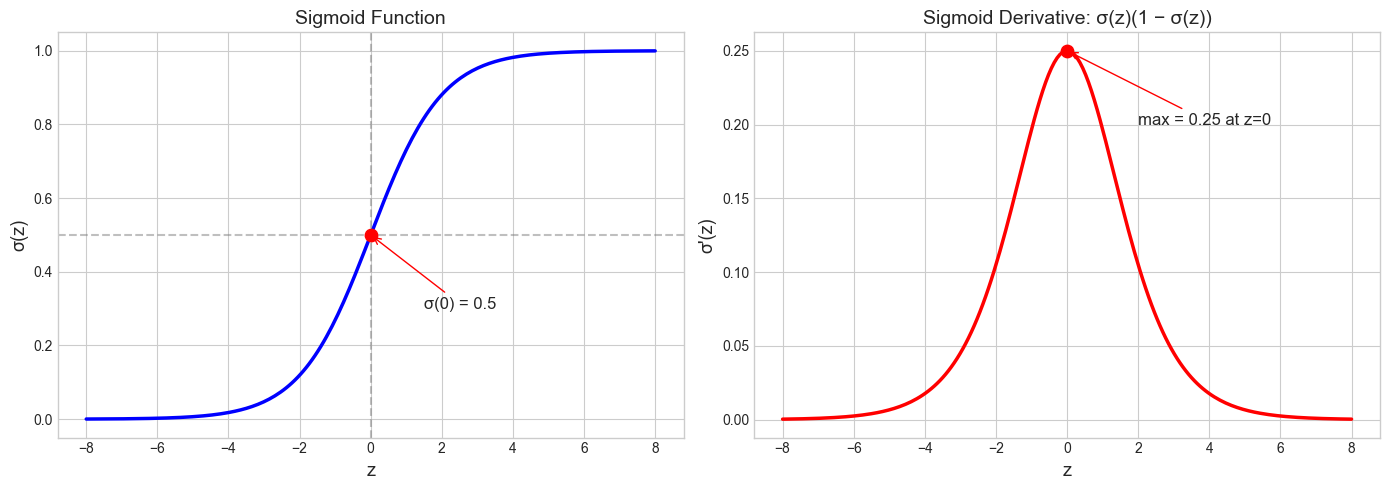

In [4]:
# Plot sigmoid and its derivative
z = np.linspace(-8, 8, 200)
sig = sigmoid(z)
sig_deriv = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid
axes[0].plot(z, sig, 'b-', linewidth=2.5)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].scatter([0], [0.5], color='red', s=80, zorder=5)
axes[0].annotate('σ(0) = 0.5', xy=(0, 0.5), xytext=(1.5, 0.3),
                 fontsize=12, arrowprops=dict(arrowstyle='->', color='red'))
axes[0].set_xlabel('z', fontsize=13)
axes[0].set_ylabel('σ(z)', fontsize=13)
axes[0].set_title('Sigmoid Function', fontsize=14)
axes[0].set_ylim(-0.05, 1.05)

# Derivative
axes[1].plot(z, sig_deriv, 'r-', linewidth=2.5)
axes[1].scatter([0], [0.25], color='red', s=80, zorder=5)
axes[1].annotate('max = 0.25 at z=0', xy=(0, 0.25), xytext=(2, 0.2),
                 fontsize=12, arrowprops=dict(arrowstyle='->', color='red'))
axes[1].set_xlabel('z', fontsize=13)
axes[1].set_ylabel("σ'(z)", fontsize=13)
axes[1].set_title('Sigmoid Derivative: σ(z)(1 − σ(z))', fontsize=14)

plt.tight_layout()
plt.savefig('assets/nb_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Binary Cross-Entropy Loss

Cross-entropy loss measures how well our predicted probabilities match the true labels. It comes from **maximum likelihood estimation** — maximizing the probability of observing the training data under our model.

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{n=1}^{N} \left[ y_n \log(\hat{y}_n) + (1-y_n) \log(1-\hat{y}_n) \right]$$

**Why not MSE?** Using MSE with sigmoid creates a non-convex loss landscape with local minima. Cross-entropy is convex for logistic regression, guaranteeing a unique global minimum.

**Intuition:** The loss is 0 when predictions are perfect, and approaches infinity when a confident prediction is wrong (e.g., predicting 0.99 for a class-0 sample).

In [5]:
def binary_cross_entropy(y_true, y_pred):
    """Compute binary cross-entropy loss."""
    epsilon = 1e-15  # Prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Demonstrate: how loss changes with prediction quality
y_true = np.array([1, 1, 0, 0])

# Good predictions
y_pred_good = np.array([0.95, 0.85, 0.1, 0.05])
loss_good = binary_cross_entropy(y_true, y_pred_good)

# Bad predictions
y_pred_bad = np.array([0.3, 0.4, 0.6, 0.7])
loss_bad = binary_cross_entropy(y_true, y_pred_bad)

print(f"Good predictions: {y_pred_good}")
print(f"BCE loss (good):  {loss_good:.4f}")
print()
print(f"Bad predictions:  {y_pred_bad}")
print(f"BCE loss (bad):   {loss_bad:.4f}")
print(f"\nBad/Good ratio: {loss_bad/loss_good:.1f}x worse")

Good predictions: [0.95 0.85 0.1  0.05]
BCE loss (good):  0.0926

Bad predictions:  [0.3 0.4 0.6 0.7]
BCE loss (bad):   1.0601

Bad/Good ratio: 11.4x worse


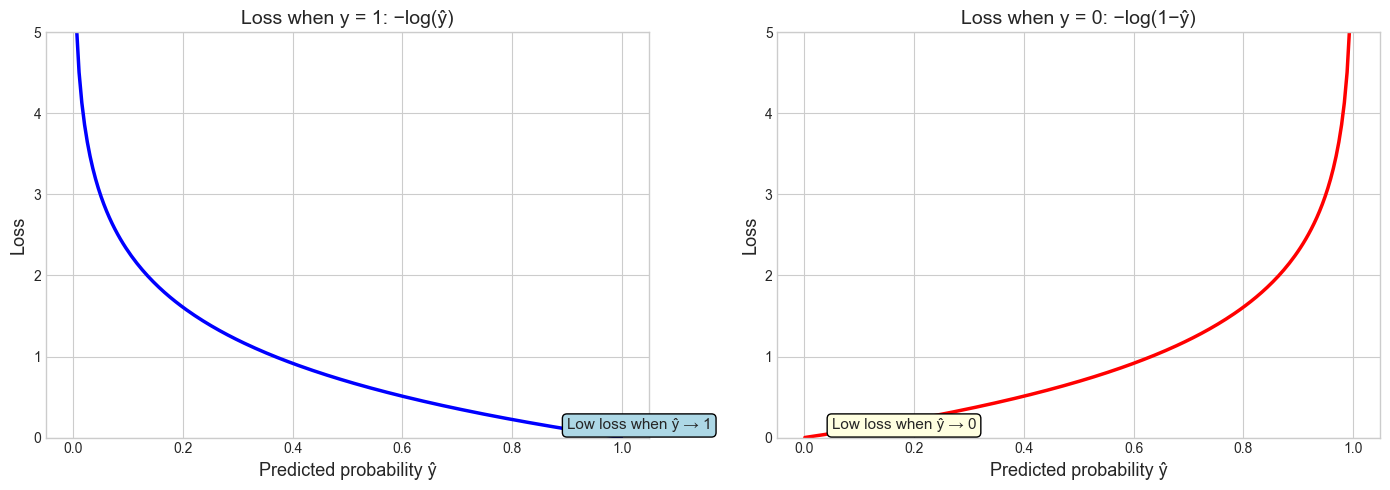

In [6]:
# Visualize loss curves for y=1 and y=0
y_hat = np.linspace(0.001, 0.999, 200)

loss_y1 = -np.log(y_hat)       # When y = 1
loss_y0 = -np.log(1 - y_hat)   # When y = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_hat, loss_y1, 'b-', linewidth=2.5)
axes[0].set_xlabel('Predicted probability ŷ', fontsize=13)
axes[0].set_ylabel('Loss', fontsize=13)
axes[0].set_title('Loss when y = 1: −log(ŷ)', fontsize=14)
axes[0].set_ylim(0, 5)
axes[0].annotate('Low loss when ŷ → 1', xy=(0.9, 0.1), fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightblue'))

axes[1].plot(y_hat, loss_y0, 'r-', linewidth=2.5)
axes[1].set_xlabel('Predicted probability ŷ', fontsize=13)
axes[1].set_ylabel('Loss', fontsize=13)
axes[1].set_title('Loss when y = 0: −log(1−ŷ)', fontsize=14)
axes[1].set_ylim(0, 5)
axes[1].annotate('Low loss when ŷ → 0', xy=(0.05, 0.1), fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig('assets/nb_cross_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Logistic Regression from Scratch

Now we implement the complete training loop using **gradient descent**. The algorithm is:

1. **Forward pass:** Compute predictions $\hat{y} = \sigma(X\mathbf{w})$
2. **Compute loss:** $\mathcal{L} = -\frac{1}{N}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$
3. **Compute gradient:** $\nabla = \frac{1}{N}X^T(\hat{y} - y) + \lambda\mathbf{w}$ (with L2 regularization)
4. **Update weights:** $\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla$
5. **Repeat** for a fixed number of epochs

We use synthetic data from `make_classification` so we can control the difficulty and visualize in 2D.

In [7]:
# Generate synthetic binary classification data
X, y = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, random_state=42
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]} samples, Test: {X_test_s.shape[0]} samples")
print(f"Class distribution (train): {np.bincount(y_train)}")

Train: 210 samples, Test: 90 samples
Class distribution (train): [104 106]


In [8]:
def logistic_regression_train(X, y, lr=0.1, epochs=200, reg=0.01):
    """Train logistic regression with gradient descent.
    
    Parameters:
        X: (N, D) feature matrix
        y: (N,) binary labels
        lr: learning rate
        epochs: number of iterations
        reg: L2 regularization strength
    
    Returns:
        w: learned weights (D+1,) including bias
        history: dict with loss and accuracy per epoch
    """
    N, D = X.shape
    X_b = np.c_[np.ones(N), X]  # Add bias column
    w = np.zeros(D + 1)
    
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(epochs):
        # Forward pass
        z = X_b @ w
        y_hat = sigmoid(z)
        
        # Compute loss
        loss = binary_cross_entropy(y, y_hat)
        acc = np.mean((y_hat >= 0.5) == y)
        history['loss'].append(loss)
        history['accuracy'].append(acc)
        
        # Gradient (with L2 regularization)
        gradient = (X_b.T @ (y_hat - y)) / N
        gradient[1:] += reg * w[1:]  # Don't regularize bias
        
        # Update
        w -= lr * gradient
    
    return w, history

# Train
w, history = logistic_regression_train(X_train_s, y_train, lr=0.1, epochs=200, reg=0.01)

print(f"Learned weights: bias={w[0]:.4f}, w1={w[1]:.4f}, w2={w[2]:.4f}")
print(f"Final loss: {history['loss'][-1]:.4f}")
print(f"Final train accuracy: {history['accuracy'][-1]:.4f}")

Learned weights: bias=0.0721, w1=0.1510, w2=2.3393
Final loss: 0.2390
Final train accuracy: 0.9048


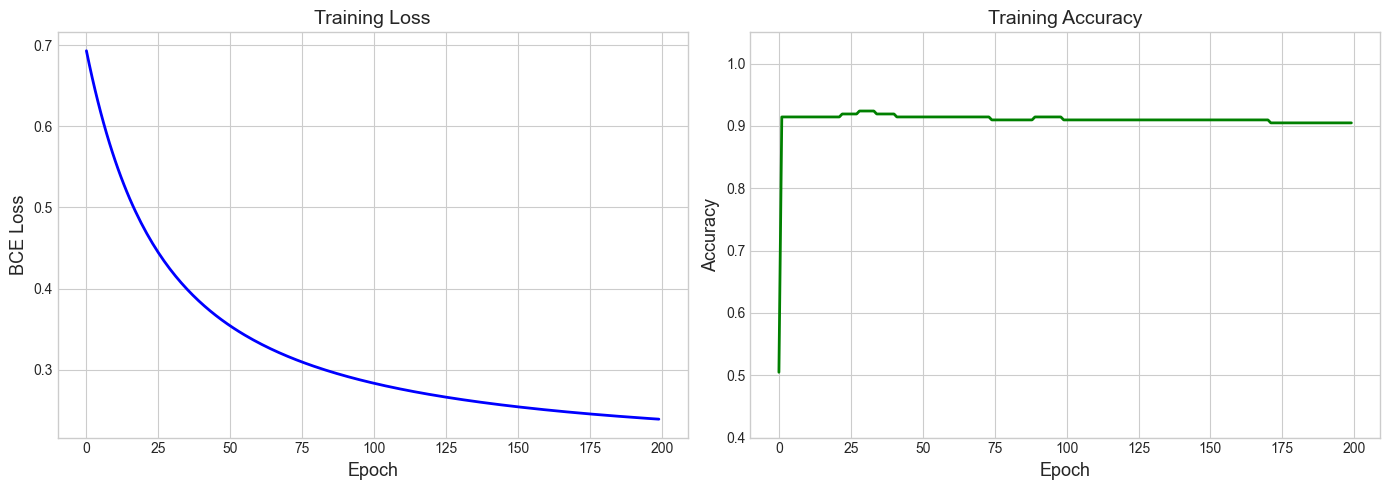

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('BCE Loss', fontsize=13)
axes[0].set_title('Training Loss', fontsize=14)

axes[1].plot(history['accuracy'], 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Accuracy', fontsize=13)
axes[1].set_title('Training Accuracy', fontsize=14)
axes[1].set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig('assets/nb_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Decision Boundary Visualization

The **decision boundary** is the set of points where $P(y=1|\mathbf{x}) = 0.5$, which corresponds to $\mathbf{w}^T\mathbf{x} = 0$.

In the visualization below, the color represents the predicted probability — blue for class 0, red for class 1, white for the boundary (P=0.5). Points near the boundary are where the model is least confident.

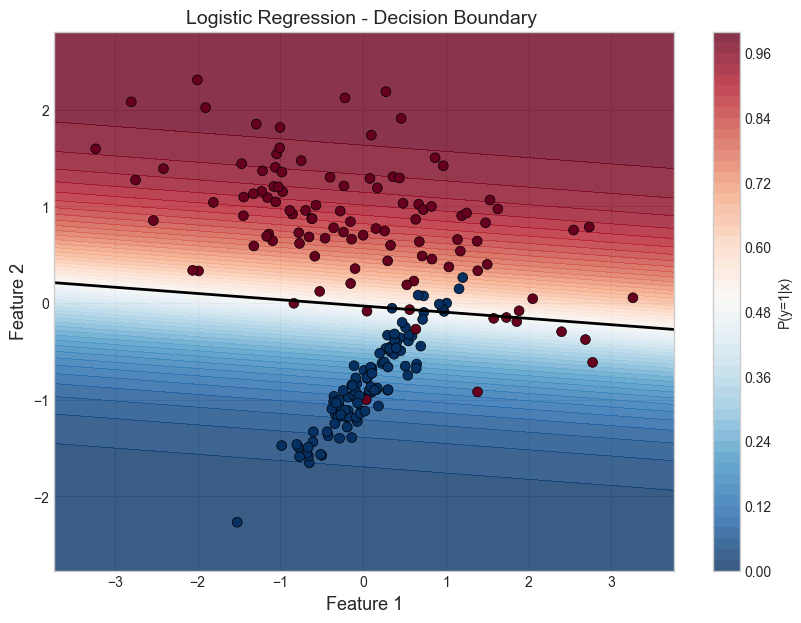

In [10]:
def plot_decision_boundary(X, y, w, title="Decision Boundary"):
    """Plot data points and decision boundary for 2D logistic regression."""
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Compute probabilities on the grid
    grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w).reshape(xx.shape)
    
    # Plot probability heatmap
    contour = ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8)
    plt.colorbar(contour, ax=ax, label='P(y=1|x)')
    
    # Plot decision boundary (P=0.5)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r',
                        edgecolors='black', s=50, linewidth=0.5)
    
    ax.set_xlabel('Feature 1', fontsize=13)
    ax.set_ylabel('Feature 2', fontsize=13)
    ax.set_title(title, fontsize=14)
    
    return fig

fig = plot_decision_boundary(X_train_s, y_train, w,
                              title="Logistic Regression - Decision Boundary ")
plt.savefig('assets/nb_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Scikit-Learn Comparison

Let's verify our from-scratch implementation by comparing weights and accuracy with scikit-learn's optimized `LogisticRegression`. The key parameter `C` is the **inverse regularization strength** ($C = 1/\lambda$) — we use a large C to minimize regularization for a fair comparison.

In [11]:
# Train with scikit-learn
model = LogisticRegression(C=100, max_iter=1000)  # C = 1/lambda
model.fit(X_train_s, y_train)

# Compare weights
print("=== Weight Comparison ===")
print(f"From scratch:   bias={w[0]:.4f}, w1={w[1]:.4f}, w2={w[2]:.4f}")
print(f"Scikit-learn:   bias={model.intercept_[0]:.4f}, w1={model.coef_[0][0]:.4f}, w2={model.coef_[0][1]:.4f}")

# Compare accuracy
y_pred_scratch = (sigmoid(np.c_[np.ones(X_test_s.shape[0]), X_test_s] @ w) >= 0.5).astype(int)
y_pred_sklearn = model.predict(X_test_s)

print(f"\n=== Test Accuracy ===")
print(f"From scratch:   {accuracy_score(y_test, y_pred_scratch):.4f}")
print(f"Scikit-learn:   {accuracy_score(y_test, y_pred_sklearn):.4f}")

=== Weight Comparison ===
From scratch:   bias=0.0721, w1=0.1510, w2=2.3393
Scikit-learn:   bias=0.1159, w1=0.5927, w2=4.9458

=== Test Accuracy ===
From scratch:   0.9556
Scikit-learn:   0.9444


---
## 6. Evaluation Metrics

Accuracy alone can be misleading (e.g., 99% accuracy on a dataset with 99% negative samples). We need:

- **Precision** = TP/(TP+FP) — "Of predicted positives, how many are correct?"
- **Recall** = TP/(TP+FN) — "Of actual positives, how many did we find?"
- **F1 Score** = harmonic mean of precision and recall
- **ROC/AUC** — performance across all thresholds

The `classification_report` gives all of these in one call.

In [12]:
# Use sklearn predictions for metrics
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# Individual metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.96      0.93      0.95        46
     Class 1       0.93      0.95      0.94        44

    accuracy                           0.94        90
   macro avg       0.94      0.94      0.94        90
weighted avg       0.94      0.94      0.94        90

Accuracy:  0.9444
Precision: 0.9333
Recall:    0.9545
F1 Score:  0.9438


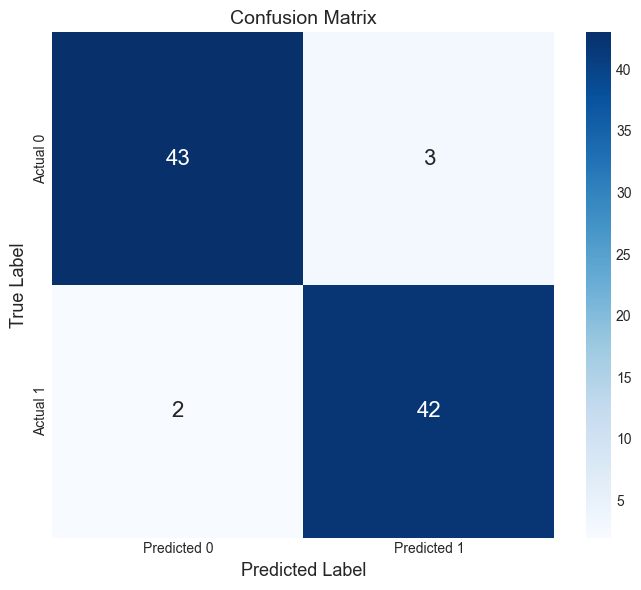


TP=42, FP=3, TN=43, FN=2


In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            annot_kws={'size': 16})
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_ylabel('True Label', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=13)

plt.tight_layout()
plt.savefig('assets/nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTP={cm[1,1]}, FP={cm[0,1]}, TN={cm[0,0]}, FN={cm[1,0]}")

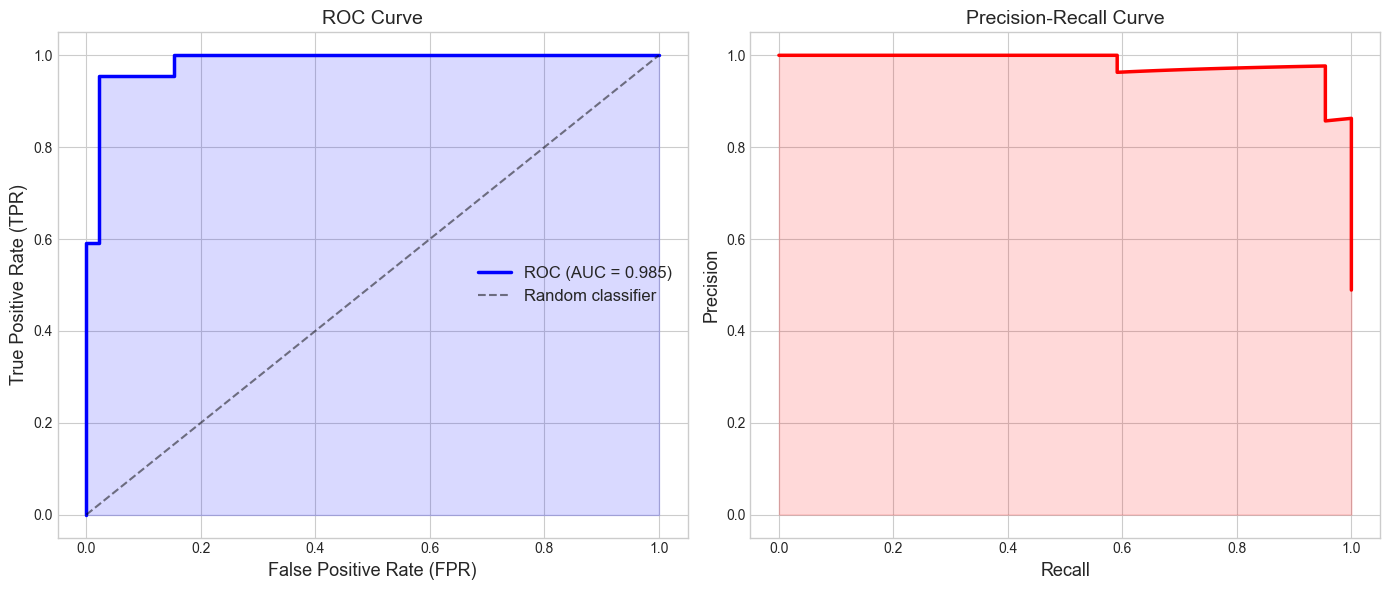

In [14]:
# ROC Curve and Precision-Recall Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=13)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=13)
axes[0].set_title('ROC Curve', fontsize=14)
axes[0].legend(fontsize=12)

# Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, 'r-', linewidth=2.5)
axes[1].fill_between(recall_vals, precision_vals, alpha=0.15, color='red')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Curve', fontsize=14)

plt.tight_layout()
plt.savefig('assets/nb_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Threshold Effect

By default, we classify as positive when $P(y=1|\mathbf{x}) \geq 0.5$. But this threshold can be adjusted:
- **Higher threshold** (e.g., 0.9): fewer false positives but more false negatives (high precision, low recall)
- **Lower threshold** (e.g., 0.1): fewer false negatives but more false positives (high recall, low precision)

The right threshold depends on the **cost of errors** in your specific application.

In [15]:
# Show how changing threshold affects precision and recall
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 55)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:>10.1f} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

 Threshold   Accuracy  Precision     Recall         F1
-------------------------------------------------------
       0.1     0.8667     0.7857     1.0000     0.8800
       0.3     0.9111     0.8750     0.9545     0.9130
       0.5     0.9444     0.9333     0.9545     0.9438
       0.7     0.9333     0.9750     0.8864     0.9286
       0.9     0.8778     0.9714     0.7727     0.8608


---
## 8. Multi-Class Classification (Softmax)

For K > 2 classes, we replace sigmoid with **softmax**: $P(y=k|\mathbf{x}) = \frac{e^{z_k}}{\sum_j e^{z_j}}$

Softmax generalizes sigmoid — it converts K raw scores into a valid probability distribution (all positive, sums to 1). Scikit-learn handles this automatically with `multi_class='multinomial'`.

We demonstrate on the **Iris dataset** (3 classes: setosa, versicolor, virginica).

In [16]:
# Softmax function
def softmax(z):
    """Numerically stable softmax."""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Demo with Iris dataset (3 classes)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Scikit-learn multinomial logistic regression
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_tr, y_tr)

y_pred_multi = model_multi.predict(X_te)
print(f"Iris 3-class accuracy: {accuracy_score(y_te, y_pred_multi):.4f}")
print()
print(classification_report(y_te, y_pred_multi, target_names=iris.target_names))

Iris 3-class accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



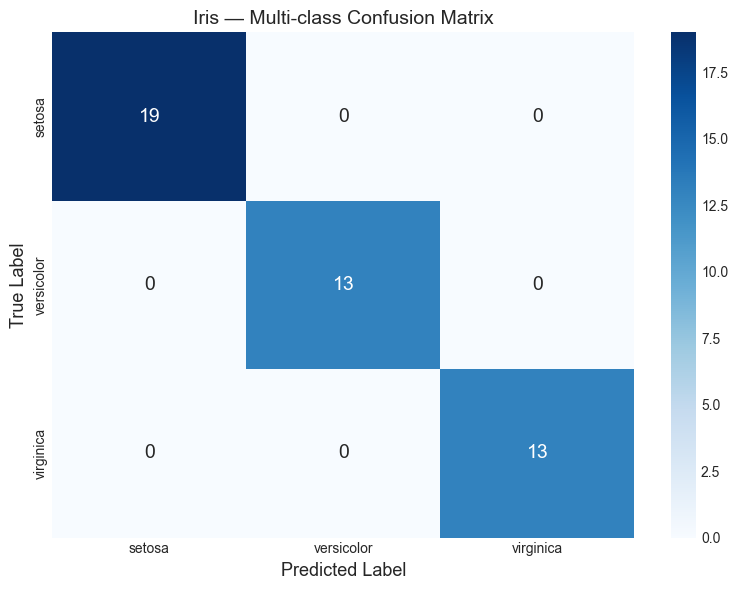

In [17]:
# Multi-class confusion matrix
cm_multi = confusion_matrix(y_te, y_pred_multi)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            annot_kws={'size': 14})
ax.set_title('Iris — Multi-class Confusion Matrix', fontsize=14)
ax.set_ylabel('True Label', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=13)

plt.tight_layout()
plt.savefig('assets/nb_iris_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Regularization Effect

Regularization prevents overfitting by penalizing large weights. In scikit-learn, the parameter `C = 1/λ`:
- **Small C** (strong regularization): weights are small, model is simple, may underfit
- **Large C** (weak regularization): weights can be large, model is complex, may overfit

The table below shows how changing C affects train/test accuracy and weight magnitudes.

In [18]:
# Compare different regularization strengths
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print(f"{'C':>8} {'λ=1/C':>10} {'Train Acc':>10} {'Test Acc':>10} {'Max |w|':>10}")
print("-" * 52)

for C in C_values:
    m = LogisticRegression(C=C, max_iter=5000)
    m.fit(X_train_s, y_train)
    train_acc = m.score(X_train_s, y_train)
    test_acc = m.score(X_test_s, y_test)
    max_w = np.max(np.abs(m.coef_))
    print(f"{C:>8.3f} {1/C:>10.3f} {train_acc:>10.4f} {test_acc:>10.4f} {max_w:>10.4f}")

       C      λ=1/C  Train Acc   Test Acc    Max |w|
----------------------------------------------------
   0.001   1000.000     0.9000     0.9222     0.0824
   0.010    100.000     0.9143     0.9444     0.5789
   0.100     10.000     0.9048     0.9556     1.9013
   1.000      1.000     0.9143     0.9556     3.6235
  10.000      0.100     0.9190     0.9444     4.7124
 100.000      0.010     0.9190     0.9444     4.9458


---
## 10. Complete Pipeline Example

In production, you should always use a **pipeline** that chains preprocessing and model into a single object. This ensures:
- Feature scaling is applied consistently (fit on train, transform on test)
- Cross-validation is done correctly (no data leakage)
- Hyperparameter tuning searches over both preprocessing and model parameters

We use `GridSearchCV` to find the best regularization strength and penalty type.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

# Build pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores: {np.round(cv_scores, 4)}")

# Hyperparameter tuning
# l1_ratio=0 → L2 regularization, l1_ratio=1 → L1 regularization
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__l1_ratio': [0, 1],
    'classifier__solver': ['saga']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

best = grid_search.best_params_
l1_ratio = best.get('classifier__l1_ratio', 0)
penalty_label = 'l1' if l1_ratio == 1 else ('l2' if l1_ratio == 0 else 'elasticnet')
print(f"\nBest parameters: C={best['classifier__C']}, penalty={penalty_label} (l1_ratio={l1_ratio})")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

5-Fold CV Accuracy: 0.9267 ± 0.0271
Per-fold scores: [0.8833 0.9167 0.9667 0.9333 0.9333]

Best parameters: C=1, penalty=l2 (l1_ratio=0)
Best F1 score: 0.9252


---
## Summary

In this notebook we:

1. **Implemented sigmoid** and verified σ(z) + σ(−z) = 1
2. **Computed BCE loss** manually and visualized its behavior
3. **Trained logistic regression from scratch** with gradient descent
4. **Visualized the decision boundary** as a probability heatmap
5. **Compared our implementation** with scikit-learn (matching results!)
6. **Evaluated with metrics**: confusion matrix, precision, recall, F1, ROC/PR curves
7. **Explored threshold effects** on precision-recall trade-off
8. **Extended to multi-class** with softmax (Iris dataset)
9. **Analyzed regularization** effect (C parameter)
10. **Built a production pipeline** with cross-validation and grid search